In [3]:

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed
import os

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import pandas as pd


#  User defined parameters
sc          = 'SOLO'
which_int   =31
load_path   = Path(root_dir).joinpath('examples').joinpath('downloaded_intervals').joinpath(sc)


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\final.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\general.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\sig_c_sig_r.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\mag_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\qtn_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\par_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO\*\sc_pot_gaps.pkl


'C:\\Users\\nokni\\work\\MHDTurbPy\\examples\\downloaded_intervals\\SOLO\\2025-03-19_00-00-00_2025-04-18_00-00-00_sc_0\\final.pkl'

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Optional, Sequence, Tuple, List
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator, FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

try:
    import pycwt
except Exception as e:
    raise ImportError("pycwt is required for this notebook cell.") from e


def require_columns(sig: pd.DataFrame, cols: Sequence[str]) -> None:
    missing = [c for c in cols if c not in sig.columns]
    if missing:
        raise KeyError("Missing required columns: %s" % missing)


def infer_dt_from_index(sig: pd.DataFrame) -> float:
    idx = sig.index
    if not isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        raise ValueError("dt not provided and cannot be inferred (index is not datetime/timedelta).")
    dt = idx.to_series().diff().dt.total_seconds().dropna().values
    if dt.size == 0:
        raise ValueError("Cannot infer dt (empty/degenerate index).")
    dt_med = np.nanmedian(dt)
    if not np.isfinite(dt_med) or dt_med <= 0:
        raise ValueError("Inferred dt is invalid.")
    return float(dt_med)


def as_float_array(x) -> np.ndarray:
    return pd.to_numeric(x, errors="coerce").astype(float).values


def runs_of_true(mask: np.ndarray) -> List[Tuple[int, int]]:
    mask = mask.astype(bool)
    if mask.size == 0:
        return []
    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends = np.where(d == -1)[0] + 1
    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size]
    return list(zip(starts.tolist(), ends.tolist()))


def choose_wavelet_grid(N: int, dt: float, dj: float, s0: Optional[float] = None, J: Optional[int] = None) -> Tuple[float, int]:
    if s0 is None:
        s0 = 2.0 * dt
    if J is None:
        J = int(np.floor(np.log2((N * dt) / s0) / dj))
        J = max(1, J)
    return float(s0), int(J)


def get_mother(mother_wave: str):
    d = {
        "gaussian": pycwt.DOG(),
        "paul": pycwt.Paul(),
        "mexican_hat": pycwt.MexicanHat(),
        "morlet": pycwt.Morlet(),
    }
    key = (mother_wave or "morlet").lower()
    return d.get(key, pycwt.Morlet())


def cwt_with_gaps(
    x: np.ndarray,
    dt: float,
    good_mask: np.ndarray,
    runs: List[Tuple[int, int]],
    dj: float,
    mother_wave: str,
    s0: float,
    J: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute CWT on each contiguous run and place into full-length arrays.
    Returns:
      W_full: (nscale, N) complex (NaN where invalid)
      freqs:  (nscale,) in Hz
      coi_full: (N,) cone-of-influence period in seconds (0 where invalid)
    """
    N = x.size
    mother = get_mother(mother_wave)

    W_full = None
    freqs_ref = None
    coi_full = np.zeros(N, dtype=float)

    for (a, b) in runs:
        if (b - a) < 4:
            continue
        xr = x[a:b].astype(float)
        if not np.all(np.isfinite(xr)):
            continue

        W, sj, freqs, coi, _, _ = pycwt.cwt(xr, dt, dj=dj, s0=s0, J=J, wavelet=mother)

        if W_full is None:
            W_full = np.full((W.shape[0], N), np.nan + 1j * np.nan, dtype=complex)
            freqs_ref = freqs.copy()

        if W.shape[0] != W_full.shape[0]:
            raise ValueError("Inconsistent wavelet grid (unexpected).")

        W_full[:, a:b] = W
        coi_full[a:b] = coi

    if W_full is None or freqs_ref is None:
        raise ValueError("No valid runs for CWT.")
    return W_full, freqs_ref, coi_full


def valid_coi_mask(freqs: np.ndarray, coi_period: np.ndarray) -> np.ndarray:
    """
    pycwt returns coi as a period (seconds). We keep coefficients where period <= coi.
    """
    period = 1.0 / freqs
    return (period[:, None] <= coi_period[None, :]) & np.isfinite(coi_period)[None, :]


def stokes_from_wavelets(
    Wp: Sequence[np.ndarray],
    Wm: Sequence[np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Wp, Wm: lists of 3 arrays (nscale, N) complex
    Returns:
      Eplus(f,t), Eminus(f,t), C(f,t)
    """
    Eplus = np.abs(Wp[0])**2 + np.abs(Wp[1])**2 + np.abs(Wp[2])**2
    Eminus = np.abs(Wm[0])**2 + np.abs(Wm[1])**2 + np.abs(Wm[2])**2
    C = Wp[0]*np.conj(Wm[0]) + Wp[1]*np.conj(Wm[1]) + Wp[2]*np.conj(Wm[2])
    return Eplus, Eminus, C


def magnetic_compressibility(
    WBr: np.ndarray,
    WBt: np.ndarray,
    WBn: np.ndarray,
    WBmag: np.ndarray,
    eps: float = 1e-30,
) -> np.ndarray:
    denom = (np.abs(WBr)**2 + np.abs(WBt)**2 + np.abs(WBn)**2)
    num = np.abs(WBmag)**2
    return num / (denom + eps)


def conditional_average_by_percentiles(
    freqs: np.ndarray,
    valid: np.ndarray,
    Eplus: np.ndarray,
    Eminus: np.ndarray,
    C: np.ndarray,
    chi: np.ndarray,
    pct_edges: Sequence[float],
) -> Dict[str, Dict[str, np.ndarray]]:
    """
    For each scale i, compute percentiles of chi[i,t] over valid times.
    Then average Eplus/Eminus/C over times in each percentile bin.
    """
    pct_edges = list(pct_edges)
    if pct_edges[0] != 0.0 or pct_edges[-1] != 100.0:
        raise ValueError("pct_edges must start at 0 and end at 100.")

    nscale, N = Eplus.shape
    nbins = len(pct_edges) - 1

    out = {}
    for b in range(nbins):
        out[b] = {
            "Eplus": np.full(nscale, np.nan),
            "Eminus": np.full(nscale, np.nan),
            "C": np.full(nscale, np.nan + 1j*np.nan, dtype=complex),
            "n": np.zeros(nscale, dtype=int),
        }

    for i in range(nscale):
        m = valid[i, :] & np.isfinite(chi[i, :]) & np.isfinite(Eplus[i, :]) & np.isfinite(Eminus[i, :]) & np.isfinite(C[i, :])
        if not np.any(m):
            continue
        vals = chi[i, m]
        q = np.nanpercentile(vals, pct_edges)

        for b in range(nbins):
            lo = q[b]
            hi = q[b + 1]
            mb = m & (chi[i, :] >= lo) & (chi[i, :] < hi if b < nbins - 1 else chi[i, :] <= hi)
            nn = int(np.sum(mb))
            out[b]["n"][i] = nn
            if nn == 0:
                continue
            out[b]["Eplus"][i] = float(np.nanmean(Eplus[i, mb]))
            out[b]["Eminus"][i] = float(np.nanmean(Eminus[i, mb]))
            out[b]["C"][i] = np.nanmean(C[i, mb])

    # finalize Stokes + p per bin
    for b in range(nbins):
        Ep = out[b]["Eplus"]
        Em = out[b]["Eminus"]
        Cb = out[b]["C"]

        I = Ep + Em
        Q = Ep - Em
        U = 2.0 * np.real(Cb)
        V = 2.0 * np.imag(Cb)

        p = np.full_like(I, np.nan, dtype=float)
        ok = np.isfinite(I) & (I > 0) & np.isfinite(Q) & np.isfinite(U) & np.isfinite(V)
        p[ok] = np.sqrt(Q[ok]**2 + U[ok]**2 + V[ok]**2) / I[ok]

        out[b].update({"freqs": freqs, "I": I, "Q": Q, "U": U, "V": V, "p": p, "Pz_plus": Ep, "Pz_minus": Em})

    return out


def make_log_bands(freqs: np.ndarray, nbands: int = 80, min_bins_per_band: int = 6) -> np.ndarray:
    fpos = freqs[np.isfinite(freqs) & (freqs > 0)]
    if fpos.size < 2 * min_bins_per_band:
        raise ValueError("Not enough positive frequency bins for banding.")
    lo = float(fpos.min())
    hi = float(fpos.max())
    max_nbands = max(3, int(fpos.size // max(1, min_bins_per_band)))
    nb = int(min(int(nbands), max_nbands))
    return np.logspace(np.log10(lo), np.log10(hi), nb + 1)


def poincare_points_from_bands_stokes_sum(
    spec_bin: Dict[str, np.ndarray],
    f_edges: np.ndarray,
    min_bins_in_band: int = 3,
) -> Dict[str, np.ndarray]:
    f = spec_bin["freqs"]
    I = spec_bin["I"]; Q = spec_bin["Q"]; U = spec_bin["U"]; V = spec_bin["V"]

    nb = len(f_edges) - 1
    q = np.full(nb, np.nan)
    u = np.full(nb, np.nan)
    v = np.full(nb, np.nan)
    p = np.full(nb, np.nan)
    fc = np.full(nb, np.nan)
    nbin = np.zeros(nb, dtype=int)

    for i in range(nb):
        f1 = float(f_edges[i]); f2 = float(f_edges[i + 1])
        m = (f >= f1) & (f < f2) & np.isfinite(I) & (I > 0) & np.isfinite(Q) & np.isfinite(U) & np.isfinite(V)
        nn = int(np.sum(m))
        nbin[i] = nn
        if nn < min_bins_in_band:
            continue
        Ibar = float(np.sum(I[m]))
        if not np.isfinite(Ibar) or Ibar <= 0:
            continue
        Qbar = float(np.sum(Q[m]))
        Ubar = float(np.sum(U[m]))
        Vbar = float(np.sum(V[m]))
        q[i] = Qbar / Ibar
        u[i] = Ubar / Ibar
        v[i] = Vbar / Ibar
        p[i] = np.sqrt(q[i]**2 + u[i]**2 + v[i]**2)
        fc[i] = np.sqrt(f1 * f2)

    return {"fc": fc, "q": q, "u": u, "v": v, "p": p, "nbin": nbin}


def plot_composite(freqs: np.ndarray, Pp: np.ndarray, Pm: np.ndarray, p: np.ndarray,
                   pts: Dict[str, np.ndarray], title: str, color_by: str = "fc") -> None:
    q = pts["q"]; u = pts["u"]; v = pts["v"]; fc = pts["fc"]; pb = pts["p"]
    mpts = np.isfinite(q) & np.isfinite(u) & np.isfinite(v) & np.isfinite(fc) & np.isfinite(pb)
    q, u, v, fc, pb = q[mpts], u[mpts], v[mpts], fc[mpts], pb[mpts]

    fig = plt.figure(figsize=(12.6, 7.2), constrained_layout=True)
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1.0, 1.30])

    ax_psd = fig.add_subplot(gs[0, 0])
    ax_p = fig.add_subplot(gs[1, 0], sharex=ax_psd)
    ax_s = fig.add_subplot(gs[:, 1], projection="3d")

    m = (freqs > 0) & np.isfinite(Pp) & np.isfinite(Pm)
    ax_psd.loglog(freqs[m], Pp[m], linewidth=2.0, label=r"$P_{z_+}(f)$ (wavelet power)")
    ax_psd.loglog(freqs[m], Pm[m], linewidth=2.0, label=r"$P_{z_-}(f)$ (wavelet power)")
    ax_psd.set_ylabel("power")
    ax_psd.grid(True, which="both", alpha=0.25)
    ax_psd.legend(loc="best")
    ax_psd.set_title(title)

    mp = (freqs > 0) & np.isfinite(p)
    ax_p.semilogx(freqs[mp], p[mp], linewidth=2.0)
    ax_p.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax_p.set_ylabel(r"$p(f)$")
    ax_p.set_ylim(-0.05, 1.05)
    ax_p.grid(True, which="both", alpha=0.25)

    th = np.linspace(0.0, np.pi, 36)
    ph = np.linspace(0.0, 2.0 * np.pi, 72)
    TH, PH = np.meshgrid(th, ph)
    X = np.sin(TH) * np.cos(PH)
    Y = np.sin(TH) * np.sin(PH)
    Z = np.cos(TH)
    ax_s.plot_wireframe(X, Y, Z, rstride=4, cstride=6, linewidth=0.5, alpha=0.22)

    if color_by == "p":
        cval = pb
        norm = Normalize(vmin=0.0, vmax=1.0)
        cbar_label = r"$p_{\mathrm{band}}$"
    else:
        cval = fc
        norm = LogNorm(vmin=float(np.nanmin(cval)), vmax=float(np.nanmax(cval)))
        cbar_label = r"$f_c\,[\mathrm{Hz}]$"

    sc = ax_s.scatter(q, u, v, c=cval, cmap="viridis", norm=norm, s=18.0, alpha=0.95, depthshade=True)
    order = np.argsort(fc)
    if fc.size > 1:
        ax_s.plot(q[order], u[order], v[order], linewidth=1.0, alpha=0.6)

    ax_s.set_xlabel(r"$q=Q/I$")
    ax_s.set_ylabel(r"$u=U/I$")
    ax_s.set_zlabel(r"$v=V/I$")
    ax_s.set_xlim(-1, 1); ax_s.set_ylim(-1, 1); ax_s.set_zlim(-1, 1)
    ax_s.view_init(elev=18.0, azim=35.0)
    try:
        ax_s.set_box_aspect((1, 1, 1))
    except Exception:
        pass

    cax = inset_axes(ax_s, width="3.5%", height="55%",
                     loc="lower left",
                     bbox_to_anchor=(1.03, 0.18, 1, 1),
                     bbox_transform=ax_s.transAxes,
                     borderpad=0.0)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label)
    if color_by != "p":
        cbar.locator = LogLocator(base=10.0, subs=(1.0,))
        cbar.formatter = FuncFormatter(lambda x, pos: r"$10^{%d}$" % int(np.round(np.log10(x))) if x > 0 else "")
        cbar.update_ticks()

    plt.show()


In [32]:
Bdf = fin['Mag']['B_resampled']

Bdf, sig = func.synchronize_dfs(Bdf, sig, upsample=False)

In [33]:
f_edges 

array([1.40523476e-04, 1.07652593e-03, 8.24707812e-03, 6.31794325e-02,
       4.84006655e-01])

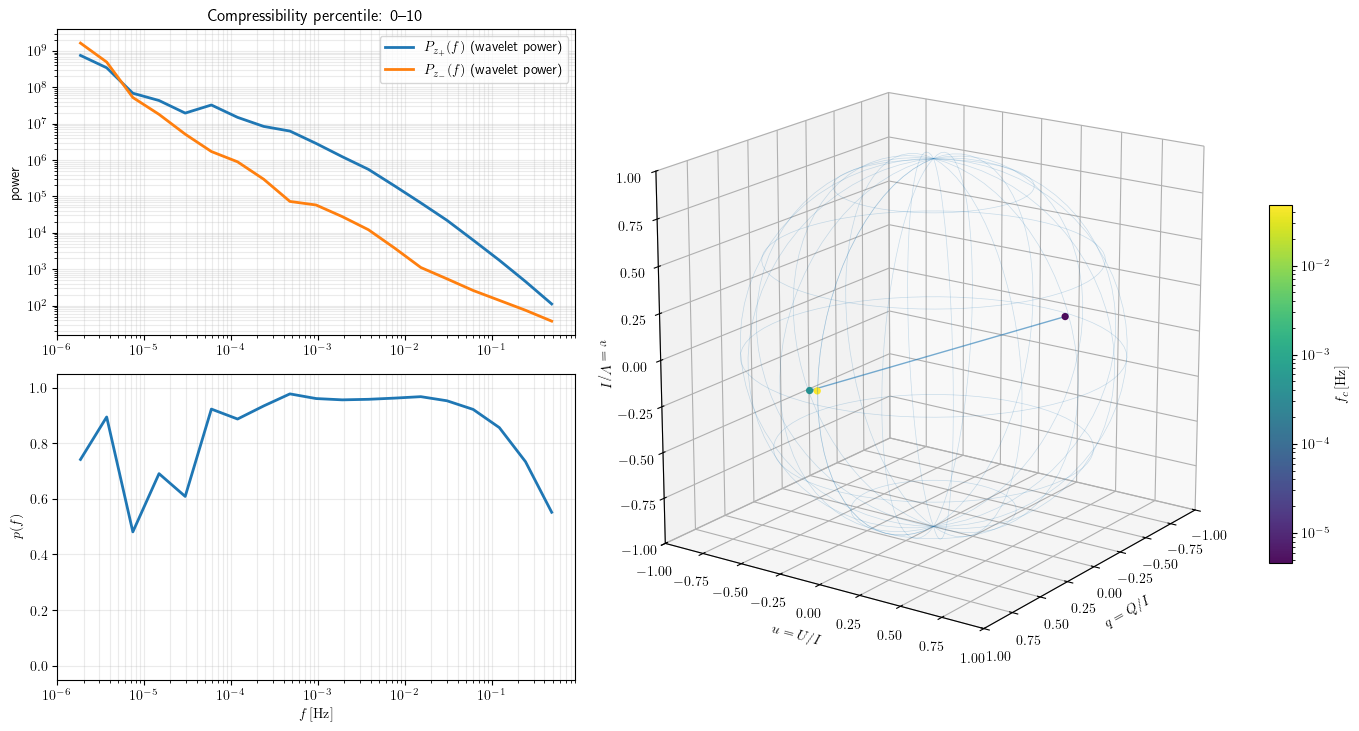

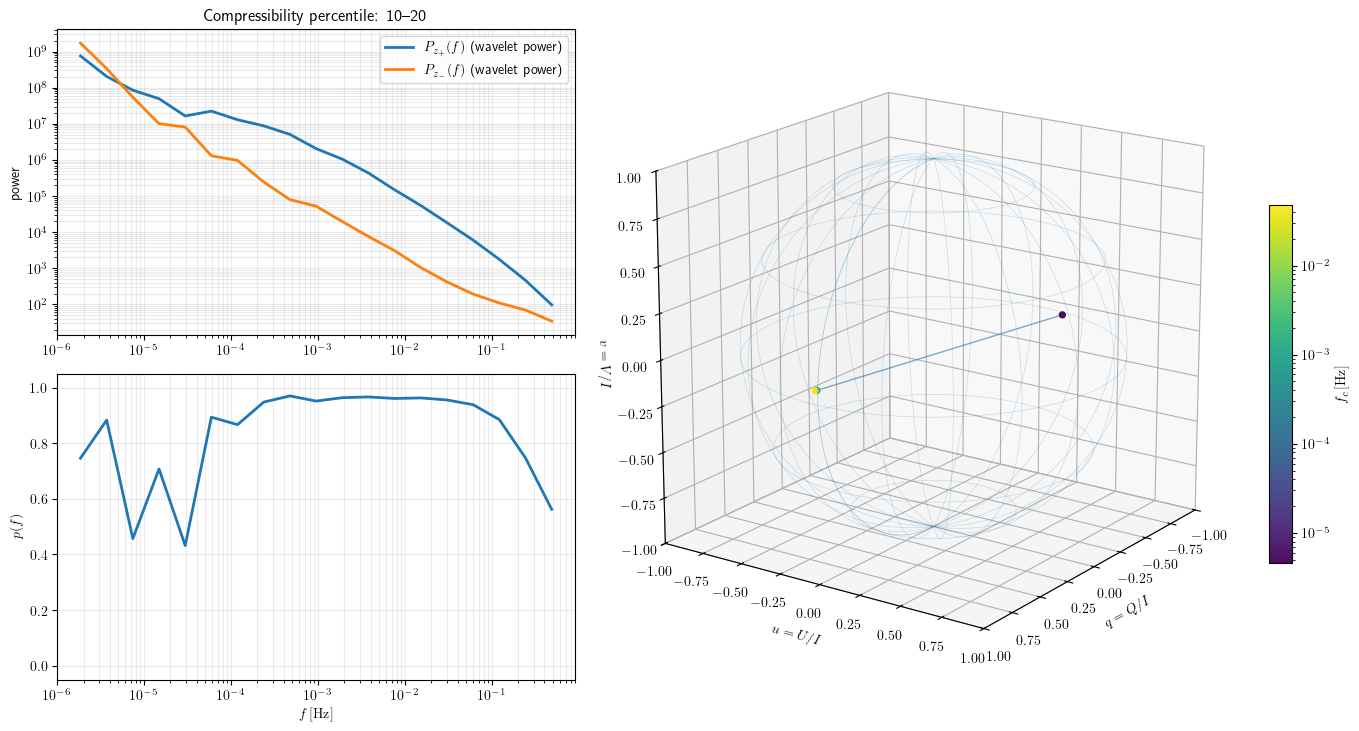

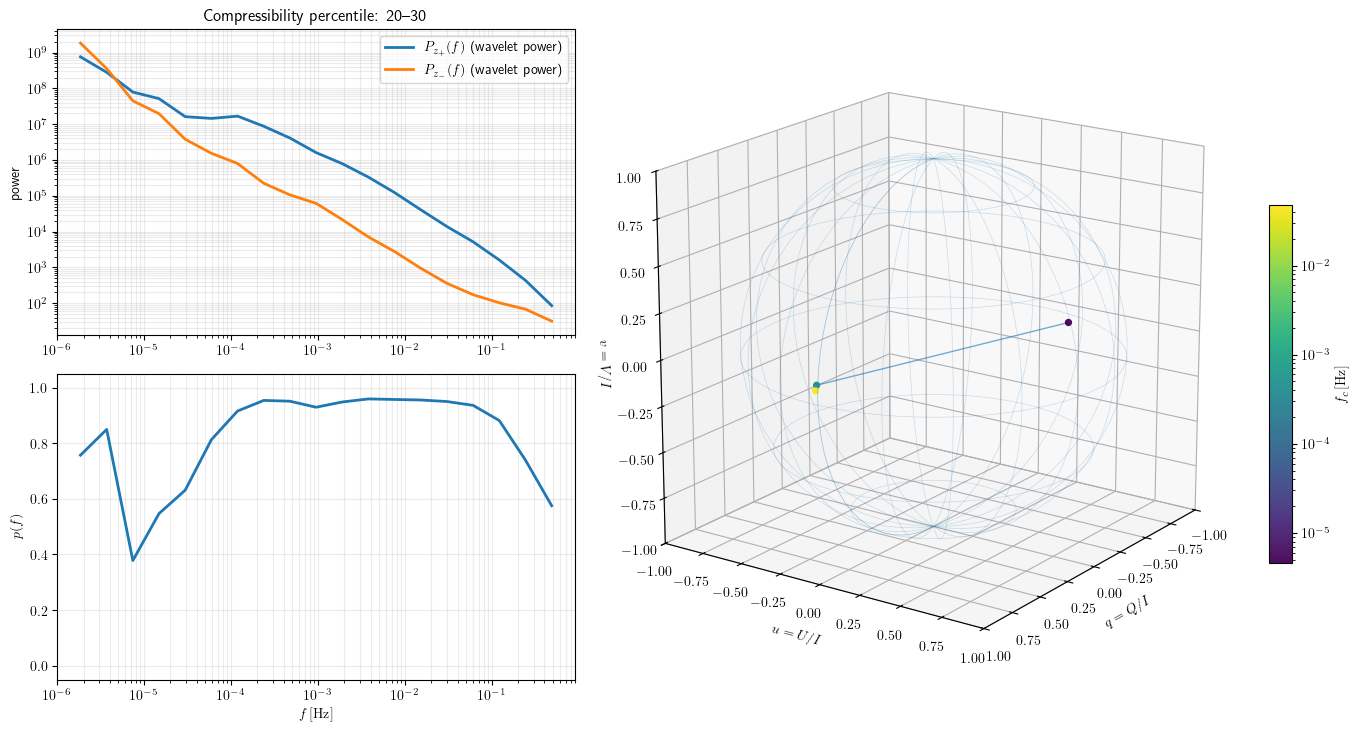

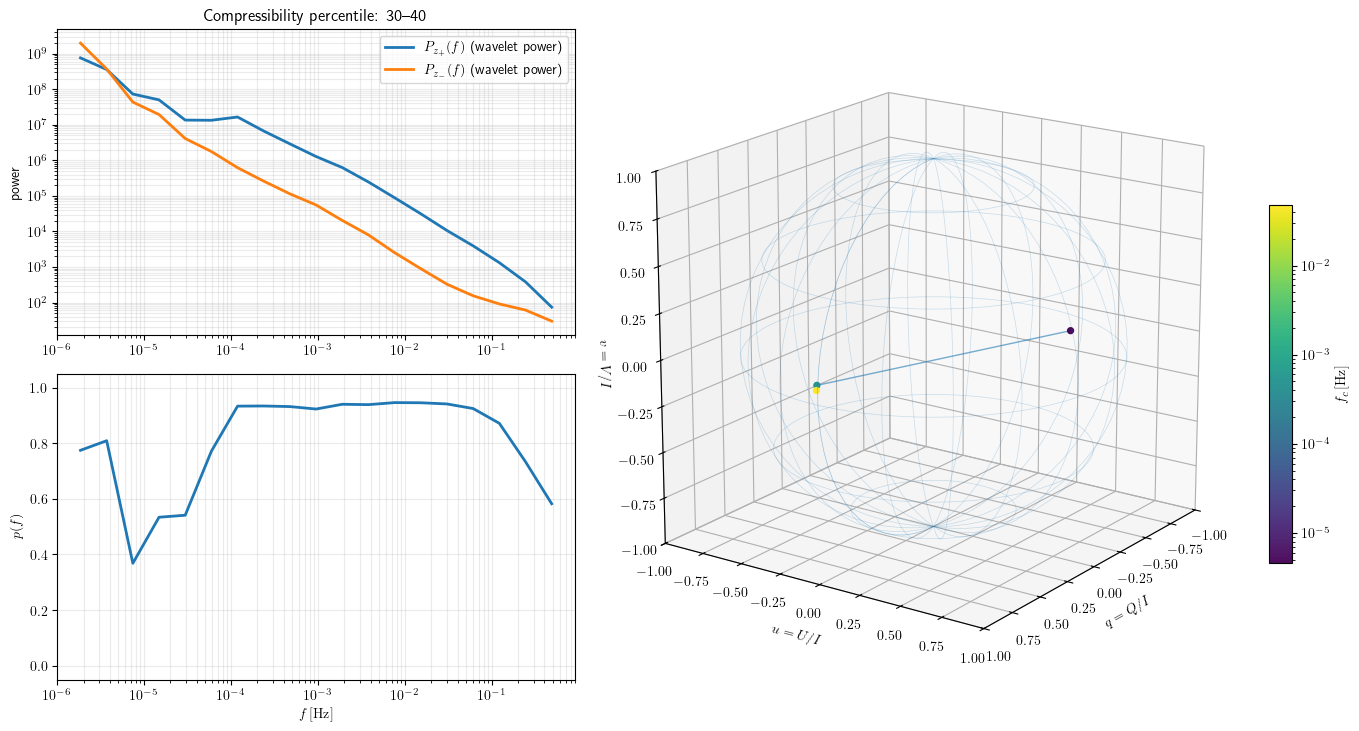

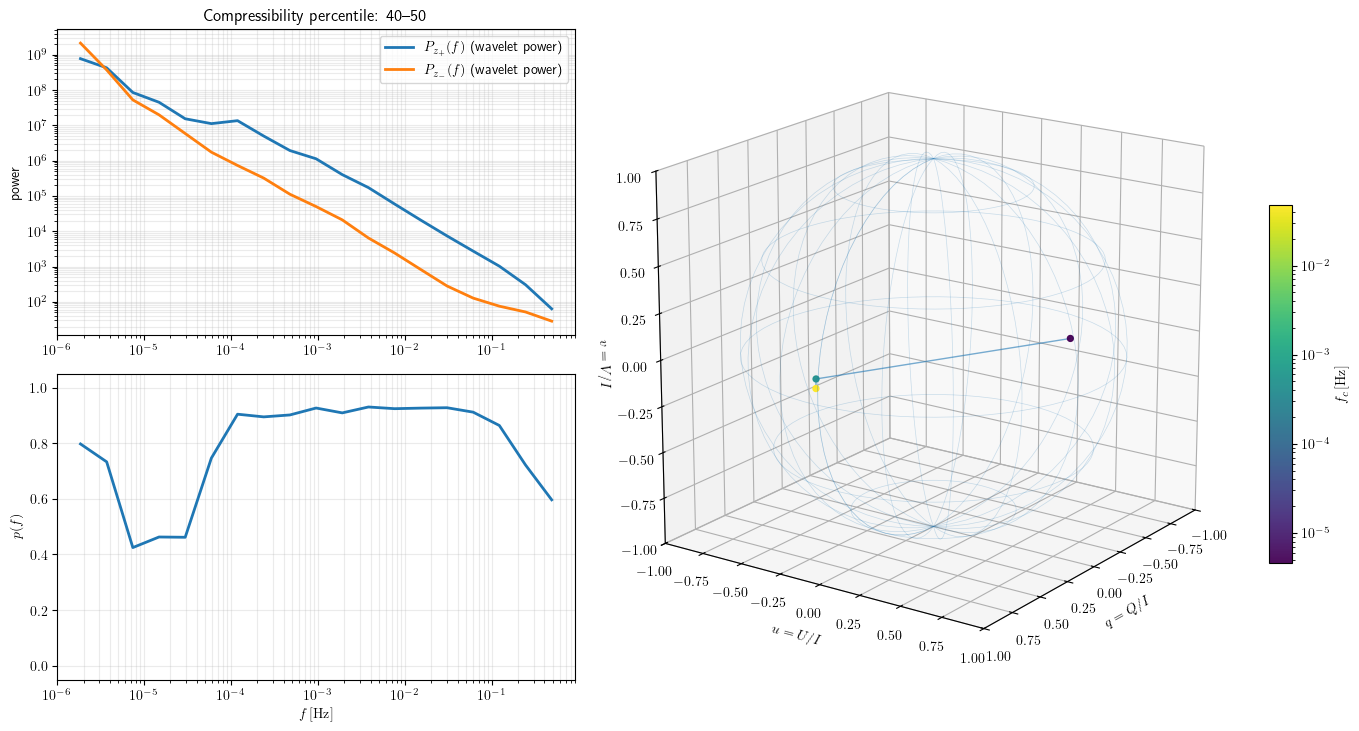

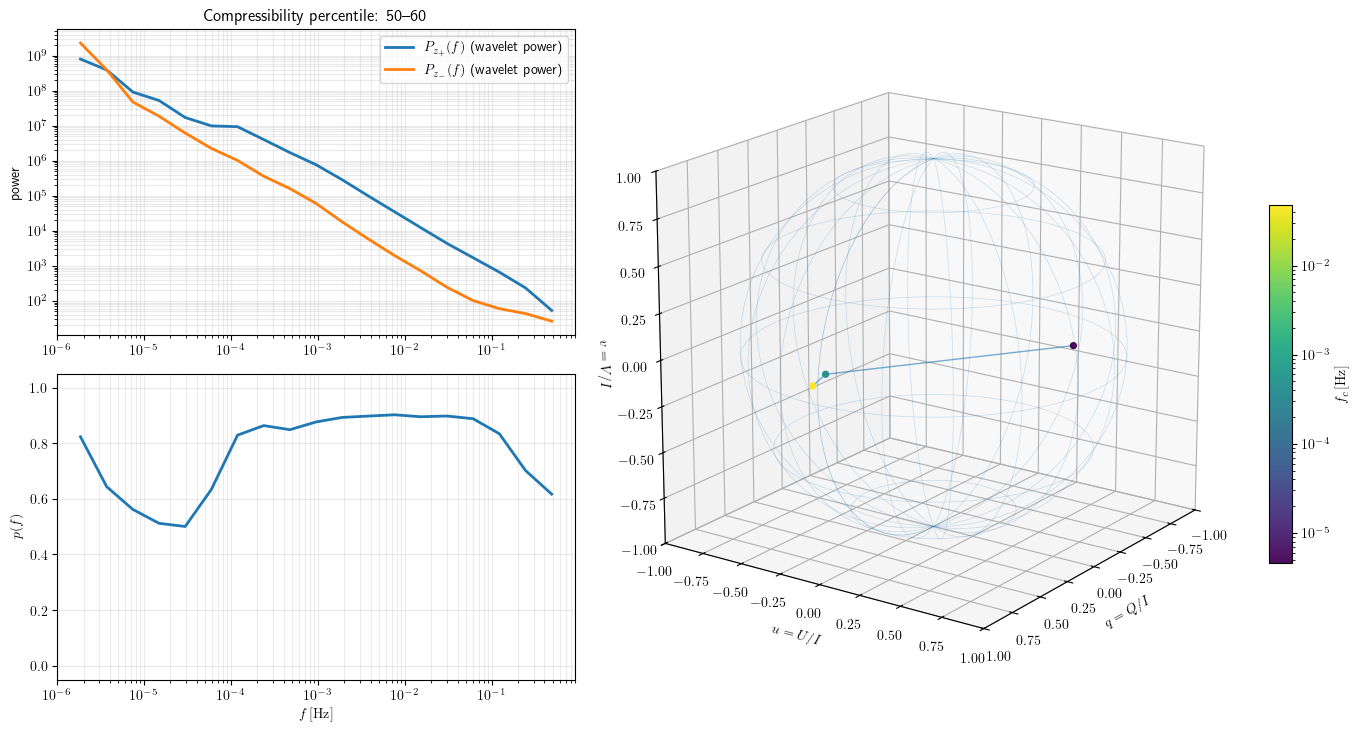

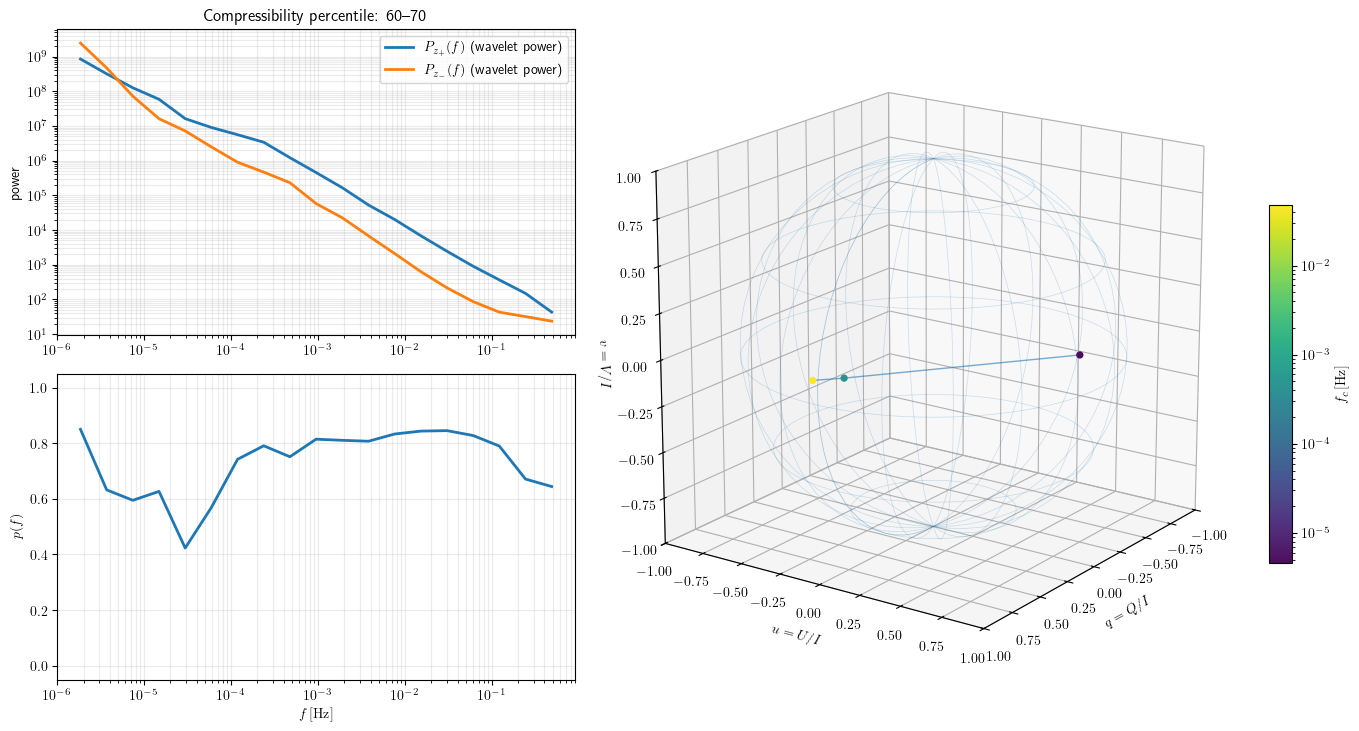

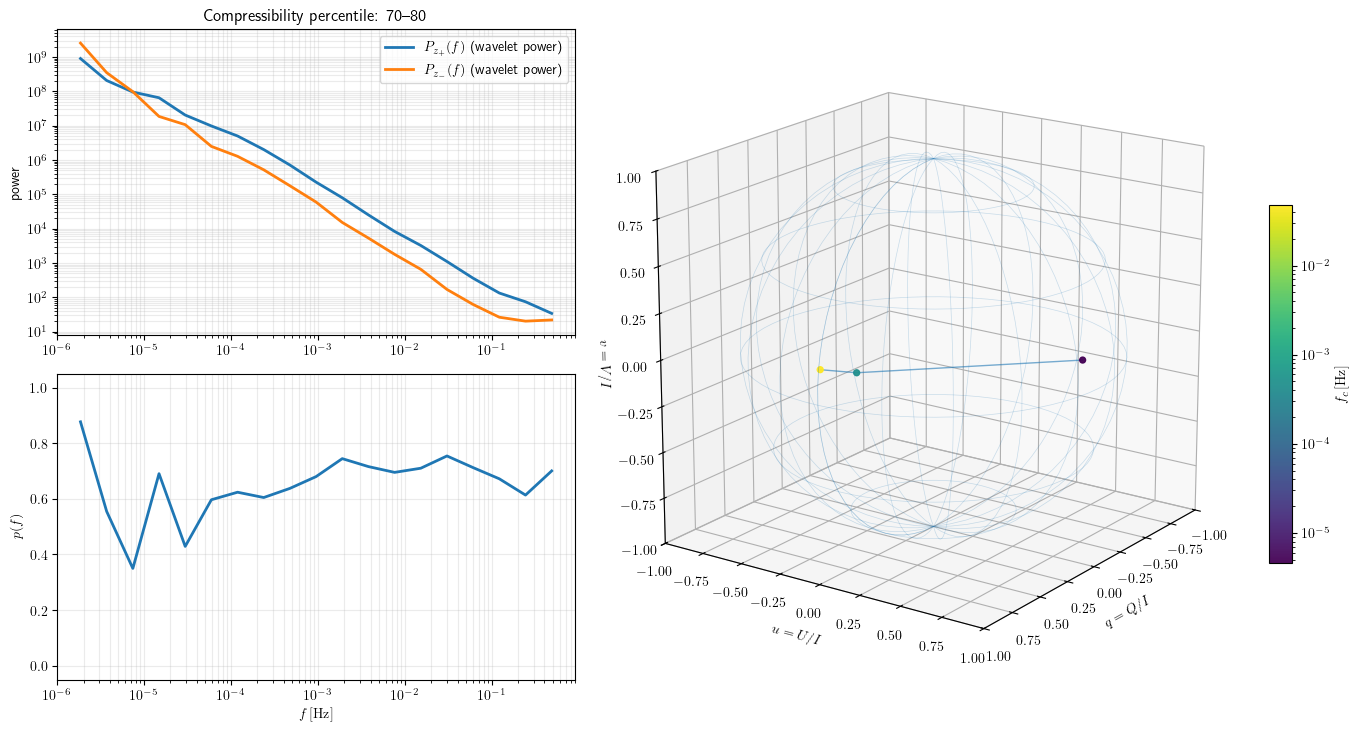

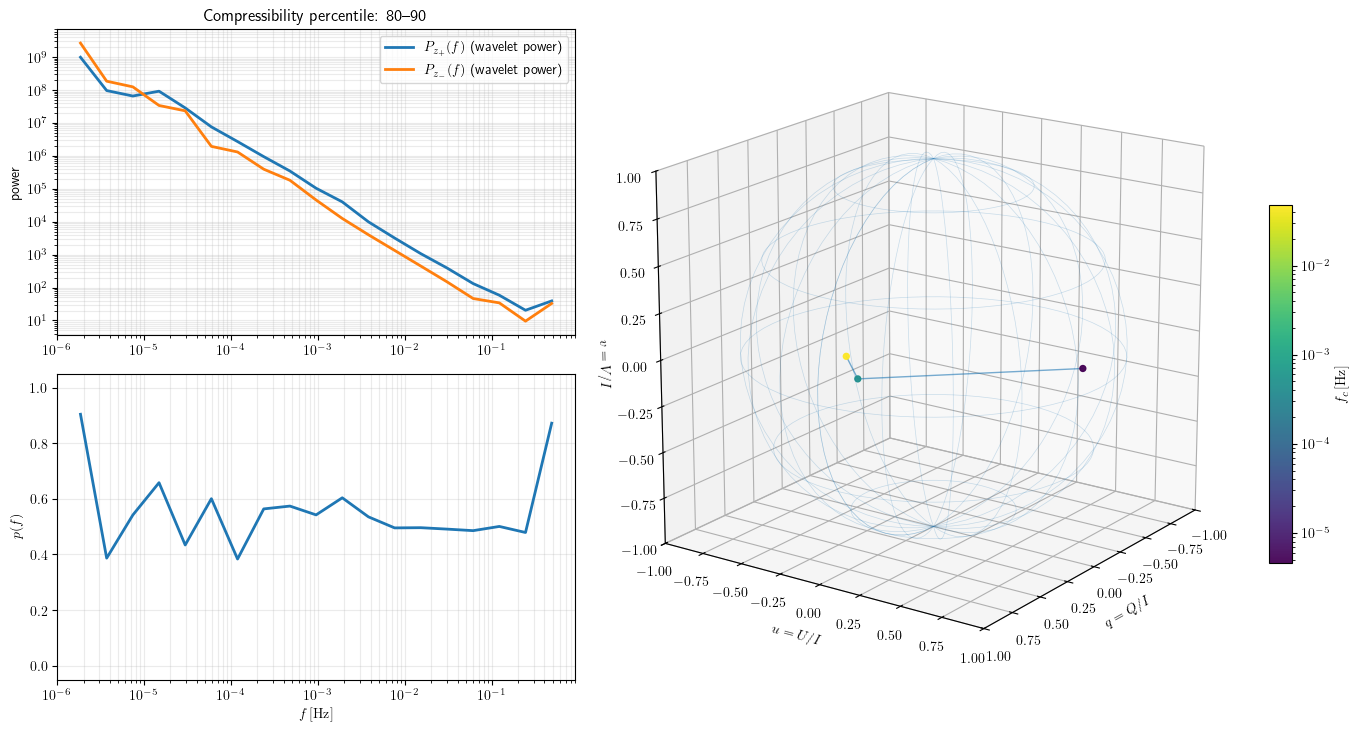

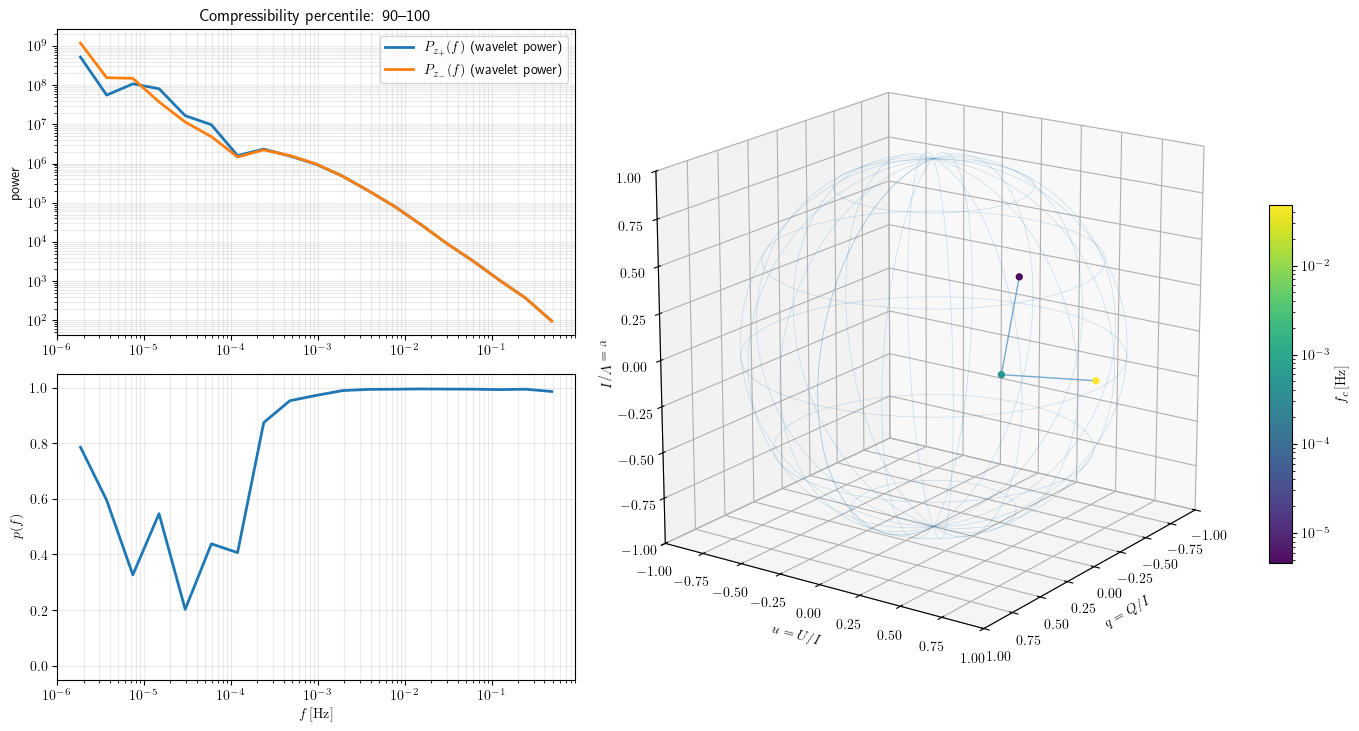

In [37]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd


def _cwt_pair_quadratics(xp, xm, dt, good, runs, dj, mother, s0, J, cast_complex64=True):
    Wp, freqs, coi = cwt_with_gaps(xp, dt, good, runs, dj, mother, s0, J)
    Wm, freqs2, coi2 = cwt_with_gaps(xm, dt, good, runs, dj, mother, s0, J)

    if freqs.shape != freqs2.shape or not np.allclose(freqs, freqs2, rtol=1e-12, atol=0.0):
        raise ValueError("Wavelet frequency grids differ between + and - components.")

    if coi.shape != coi2.shape or not np.allclose(coi, coi2, rtol=1e-12, atol=0.0):
        raise ValueError("Wavelet COI arrays differ between + and - components.")

    if cast_complex64:
        Wp = Wp.astype(np.complex64, copy=False)
        Wm = Wm.astype(np.complex64, copy=False)

    Ep = np.abs(Wp) ** 2
    Em = np.abs(Wm) ** 2
    C = Wp * np.conj(Wm)
    return Ep, Em, C, freqs, coi


def _cwt_power(x, dt, good, runs, dj, mother, s0, J, cast_float32=True):
    W, freqs, coi = cwt_with_gaps(x, dt, good, runs, dj, mother, s0, J)
    P = np.abs(W) ** 2
    if cast_float32:
        P = P.astype(np.float32, copy=False)
    return P, freqs, coi


def conditional_average_by_percentiles_parallel(
    freqs,
    valid,
    Eplus_ft,
    Eminus_ft,
    C_ft,
    chi,
    pct_edges,
    n_jobs=-1,
    prefer="threads",
):
    pct_edges = np.asarray(pct_edges, dtype=float)
    if pct_edges.ndim != 1 or pct_edges.size < 2:
        raise ValueError("pct_edges must be a 1D array of at least two values.")
    if pct_edges[0] != 0.0 or pct_edges[-1] != 100.0:
        raise ValueError("pct_edges must start at 0 and end at 100.")
    if not np.all(np.diff(pct_edges) > 0):
        raise ValueError("pct_edges must be strictly increasing.")

    nscale, Nt = Eplus_ft.shape
    nbins = int(pct_edges.size - 1)

    def _reduce_scale(i):
        m = valid[i, :] & np.isfinite(chi[i, :]) & np.isfinite(Eplus_ft[i, :]) & np.isfinite(Eminus_ft[i, :]) & np.isfinite(C_ft[i, :])
        if not np.any(m):
            Ep = np.full(nbins, np.nan, dtype=float)
            Em = np.full(nbins, np.nan, dtype=float)
            Cb = np.full(nbins, np.nan + 1j * np.nan, dtype=complex)
            nn = np.zeros(nbins, dtype=int)
            return i, Ep, Em, Cb, nn

        vals = chi[i, m]
        q = np.nanpercentile(vals, pct_edges)

        Ep = np.full(nbins, np.nan, dtype=float)
        Em = np.full(nbins, np.nan, dtype=float)
        Cb = np.full(nbins, np.nan + 1j * np.nan, dtype=complex)
        nn = np.zeros(nbins, dtype=int)

        for b in range(nbins):
            lo = q[b]
            hi = q[b + 1]
            mb = m & (chi[i, :] >= lo) & ((chi[i, :] < hi) if b < (nbins - 1) else (chi[i, :] <= hi))
            n = int(np.sum(mb))
            nn[b] = n
            if n == 0:
                continue
            Ep[b] = float(np.nanmean(Eplus_ft[i, mb]))
            Em[b] = float(np.nanmean(Eminus_ft[i, mb]))
            Cb[b] = np.nanmean(C_ft[i, mb])

        return i, Ep, Em, Cb, nn

    reduced = Parallel(n_jobs=n_jobs, prefer=prefer)(
        delayed(_reduce_scale)(i) for i in range(nscale)
    )

    Ep_bin = np.full((nbins, nscale), np.nan, dtype=float)
    Em_bin = np.full((nbins, nscale), np.nan, dtype=float)
    C_bin = np.full((nbins, nscale), np.nan + 1j * np.nan, dtype=complex)
    N_bin = np.zeros((nbins, nscale), dtype=int)

    for i, Ep, Em, Cb, nn in reduced:
        Ep_bin[:, i] = Ep
        Em_bin[:, i] = Em
        C_bin[:, i] = Cb
        N_bin[:, i] = nn

    bins = {}
    for b in range(nbins):
        Ep = Ep_bin[b, :]
        Em = Em_bin[b, :]
        Cb = C_bin[b, :]

        I = Ep + Em
        Q = Ep - Em
        U = 2.0 * np.real(Cb)
        V = 2.0 * np.imag(Cb)

        p = np.full_like(I, np.nan, dtype=float)
        ok = np.isfinite(I) & (I > 0) & np.isfinite(Q) & np.isfinite(U) & np.isfinite(V)
        p[ok] = np.sqrt(Q[ok] ** 2 + U[ok] ** 2 + V[ok] ** 2) / I[ok]

        bins[b] = {
            "freqs": freqs,
            "Eplus": Ep,
            "Eminus": Em,
            "C": Cb,
            "I": I,
            "Q": Q,
            "U": U,
            "V": V,
            "p": p,
            "Pz_plus": Ep,
            "Pz_minus": Em,
            "n": N_bin[b, :],
        }

    return bins


def run_wavelet_conditional_pipeline(
    sig,
    Bdf,
    cols_plus=("Zpr", "Zpt", "Zpn"),
    cols_minus=("Zmr", "Zmt", "Zmn"),
    cols_B=("Br", "Bt", "Bn"),
    gap_factor=5.0,
    dj=1,
    mother="morlet",
    pct_step=10,
    nbands=80,
    min_bins_per_band=12,
    min_bins_in_band=3,
    n_jobs=-1,
    prefer="threads",
):
    pct_edges = np.arange(0.0, 100.0 + float(pct_step), float(pct_step))

    dt = infer_dt_from_index(sig)

    require_columns(sig, list(cols_plus) + list(cols_minus))
    require_columns(Bdf, list(cols_B))

    Zp = [as_float_array(sig[c]) for c in cols_plus]
    Zm = [as_float_array(sig[c]) for c in cols_minus]
    Br, Bt, Bn = [as_float_array(Bdf[c]) for c in cols_B]
    Bmag = np.sqrt(Br ** 2 + Bt ** 2 + Bn ** 2)

    good = np.isfinite(Zp[0])
    for a in Zp[1:] + Zm + [Br, Bt, Bn, Bmag]:
        good &= np.isfinite(a)

    if isinstance(sig.index, pd.DatetimeIndex):
        dts = sig.index.to_series().diff().dt.total_seconds().values
        big_gap = np.zeros(len(good), dtype=bool)
        big_gap[1:] = np.isfinite(dts[1:]) & (dts[1:] > float(gap_factor) * float(dt))
        good[big_gap] = False

    runs = runs_of_true(good)
    if len(runs) == 0:
        raise ValueError("No usable contiguous data after gap/NaN masking.")

    s0, J = choose_wavelet_grid(len(good), dt, dj)

    pair_results = Parallel(n_jobs=n_jobs, prefer=prefer)(
        delayed(_cwt_pair_quadratics)(Zp[j], Zm[j], dt, good, runs, dj, mother, s0, J) for j in range(3)
    )

    freqs = pair_results[0][3]
    coi = pair_results[0][4]

    Eplus_ft = pair_results[0][0].astype(np.float32, copy=True)
    Eminus_ft = pair_results[0][1].astype(np.float32, copy=True)
    C_ft = pair_results[0][2].astype(np.complex64, copy=True)

    for j in range(1, 3):
        Eplus_ft += pair_results[j][0].astype(np.float32, copy=False)
        Eminus_ft += pair_results[j][1].astype(np.float32, copy=False)
        C_ft += pair_results[j][2].astype(np.complex64, copy=False)

    B_results = Parallel(n_jobs=n_jobs, prefer=prefer)(
        delayed(_cwt_power)(arr, dt, good, runs, dj, mother, s0, J) for arr in (Br, Bt, Bn, Bmag)
    )

    PBr, fB0, coiB0 = B_results[0]
    PBt, fB1, coiB1 = B_results[1]
    PBn, fB2, coiB2 = B_results[2]
    PBmag, fB3, coiB3 = B_results[3]

    if not (np.allclose(freqs, fB0) and np.allclose(freqs, fB1) and np.allclose(freqs, fB2) and np.allclose(freqs, fB3)):
        raise ValueError("Wavelet frequency grids differ between z and B transforms.")
    if not (np.allclose(coi, coiB0) and np.allclose(coi, coiB1) and np.allclose(coi, coiB2) and np.allclose(coi, coiB3)):
        raise ValueError("Wavelet COI differs between z and B transforms.")

    valid = valid_coi_mask(freqs, coi)

    eps = 1e-30
    chi = PBmag / (PBr + PBt + PBn + eps)

    bins = conditional_average_by_percentiles_parallel(
        freqs=freqs,
        valid=valid,
        Eplus_ft=Eplus_ft,
        Eminus_ft=Eminus_ft,
        C_ft=C_ft,
        chi=chi,
        pct_edges=pct_edges,
        n_jobs=n_jobs,
        prefer=prefer,
    )

    f_edges = make_log_bands(freqs, nbands=nbands, min_bins_per_band=min_bins_per_band)

    for b in range(len(pct_edges) - 1):
        specb = bins[b]
        ptsb = poincare_points_from_bands_stokes_sum(specb, f_edges, min_bins_in_band=min_bins_in_band)
        title = "Compressibility percentile: %g–%g" % (pct_edges[b], pct_edges[b + 1])
        plot_composite(specb["freqs"], specb["Pz_plus"], specb["Pz_minus"], specb["p"], ptsb, title, color_by="fc")

    return {"bins": bins, "pct_edges": pct_edges, "freqs": freqs, "f_edges": f_edges}


# ---- call (your variables sig, Bdf must exist) ----
out = run_wavelet_conditional_pipeline(
    sig=sig,
    Bdf=Bdf,
    cols_plus=("Zpr", "Zpt", "Zpn"),
    cols_minus=("Zmr", "Zmt", "Zmn"),
    cols_B=("Br", "Bt", "Bn"),
    gap_factor=5.0,
    dj=1,
    mother="morlet",
    pct_step=10,
    nbands=80,
    min_bins_per_band=6,
    min_bins_in_band=3,
    n_jobs=-1,
    prefer="threads",
)


In [28]:
f_edges

array([1.40523476e-04, 1.07652593e-03, 8.24707812e-03, 6.31794325e-02,
       4.84006655e-01])